<a href="https://colab.research.google.com/github/yogakun01/UTS-Natural-Language-Processing-NLP---sistem-Analisis-Sentimen-Ulasan-Film/blob/main/UTS_NLP_Sistem_Analisis_Sentimen_Ulasan_Film.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 UTS Natural Language Processing (NLP)
**Primakara University**

---

Nama  : I Made Sedana Yoga  
NIM   : 2301020063  
Kelas : IF Pagi 2

---

## 📋 Deskripsi Proyek
Proyek ini membangun sistem **Analisis Sentimen Ulasan Film** berbasis Python yang menerapkan konsep-konsep NLP:
- **Text Preprocessing**: cleaning, tokenization, stopword removal, stemming
- **Representasi Teks**: Bag-of-Words (BoW) dan TF-IDF
- **Word Embeddings**: Word2Vec
- **Klasifikasi**: Naive Bayes dan Logistic Regression
- **Visualisasi**: Word Cloud, distribusi token, TF-IDF plot, PCA embedding

**Dataset:** Dataset IMDB berisi 50.000 ulasan film.
Tersedia di Kaggle:
https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

---
# Bagian 0 — Instalasi & Import Library

Langkah pertama adalah menginstall dan mengimport semua library yang dibutuhkan.
Library utama yang digunakan:
- **NLTK**: toolkit NLP untuk tokenisasi, stopword, stemming
- **Gensim**: untuk training model Word2Vec
- **Scikit-learn**: untuk vektorisasi (BoW, TF-IDF) dan klasifikasi
- **WordCloud**: untuk visualisasi kata
- **Matplotlib / Seaborn**: untuk plotting

In [ ]:
# Install library yang dibutuhkan (hanya perlu dijalankan sekali)
!pip install nltk gensim wordcloud scikit-learn pandas numpy matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 76.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK — Natural Language Toolkit
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Scikit-learn — Machine Learning
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

# Gensim — Word2Vec
from gensim.models import Word2Vec

# WordCloud
from wordcloud import WordCloud

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


---
# Bagian 1 — Load Dataset

Dataset yang digunakan adalah **Dataset IMDB berisi 50.000 ulasan film**.
Dataset ini terdiri dari 50000 ulasan film (25000 positif, 25000 negatif) yang dibuat secara terprogram untuk keperluan pengujian.

Setiap ulasan dikombinasikan dari beberapa template kalimat sehingga menghasilkan variasi teks yang cukup realistis.

In [ ]:
# Load dataset IMDB 50K
df = pd.read_csv('/content/IMDB Dataset.csv')

# Acak data (opsional)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("✅ Dataset berhasil dimuat!")
print("Total data:", len(df))

print("Distribusi:")
print(df['sentiment'].value_counts())

df.head()

✅ Dataset berhasil dimuat!
Total data: 50000
Distribusi:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative


In [ ]:
# Tampilkan 5 baris pertama dataset
print('=== 10 Sampel Data Pertama ===')
df.head()

=== 10 Sampel Data Pertama ===


,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative


In [ ]:
# Informasi umum dataset
print('=== Informasi Dataset ===')
print(f'Shape       : {df.shape}  (baris x kolom)')
print(f'Kolom       : {list(df.columns)}')
print(f'Missing values:')
print(df.isnull().sum())

=== Informasi Dataset ===
Shape       : (50000, 2)  (baris x kolom)
Kolom       : ['review', 'sentiment']
Missing values:
review       0
sentiment    0
dtype: int64


---
# Bagian 2 — Text Preprocessing

Preprocessing adalah tahap paling penting dalam pipeline NLP. Tujuannya adalah membersihkan dan menyederhanakan teks mentah agar lebih mudah diproses oleh model.

Tahapan preprocessing yang dilakukan:

| No | Tahap | Keterangan |
|---|---|---|
| 1 | **Cleaning** | Huruf kecil, hapus HTML tag, URL, angka, tanda baca |
| 2 | **Tokenization** | Pecah kalimat menjadi daftar kata (token) |
| 3 | **Stopword Removal** | Hapus kata umum tidak bermakna (the, is, a, ...) |
| 4 | **Stemming** | Potong kata ke bentuk akar (running → run) |
| 5 | **Lemmatization** | Ubah kata ke bentuk kamus (better → good) |

In [ ]:
# Inisialisasi tools preprocessing
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def text_cleaning(text):
    """Membersihkan teks dari karakter tidak relevan."""
    text = text.lower()                          # Ubah ke huruf kecil
    text = re.sub(r'<.*?>', '', text)            # Hapus HTML tags
    text = re.sub(r'http\S+|www\.\S+', '', text) # Hapus URL
    text = re.sub(r'[^a-z\s]', '', text)          # Hapus angka & tanda baca
    text = re.sub(r'\s+', ' ', text).strip()     # Hapus spasi berlebih
    return text

def tokenize(text):
    """Tokenisasi teks menjadi daftar kata."""
    return word_tokenize(text)

def remove_stopwords(tokens):
    """Menghapus stopwords dan token pendek (< 3 karakter)."""
    return [t for t in tokens if t not in stop_words and len(t) > 2]

def stemming(tokens):
    """Menerapkan Porter Stemming pada setiap token."""
    return [stemmer.stem(t) for t in tokens]

def lemmatization(tokens):
    """Menerapkan WordNet Lemmatization pada setiap token."""
    return [lemmatizer.lemmatize(t) for t in tokens]

def full_preprocessing(text, use_stemming=True):
    """Pipeline preprocessing lengkap dari teks mentah ke list token."""
    cleaned = text_cleaning(text)
    tokens  = tokenize(cleaned)
    tokens  = remove_stopwords(tokens)
    tokens  = stemming(tokens) if use_stemming else lemmatization(tokens)
    return tokens

print('✅ Fungsi preprocessing berhasil didefinisikan!')

✅ Fungsi preprocessing berhasil didefinisikan!


In [ ]:
# Demo preprocessing pada 1 contoh teks
sample_text = df['review'].iloc[0]
print('=== DEMO STEP-BY-STEP PREPROCESSING ===')
print(f'\n📝 Teks Asli:')
print(sample_text[:200])

cleaned = text_cleaning(sample_text)
print(f'\n🧹 Setelah Cleaning:')
print(cleaned[:200])

tokens = tokenize(cleaned)
print(f'\n✂️  Setelah Tokenisasi (10 pertama): {tokens[:10]}')

tokens_no_sw = remove_stopwords(tokens)
print(f'\n🚫 Setelah Stopword Removal (10 pertama): {tokens_no_sw[:10]}')

tokens_stemmed = stemming(tokens_no_sw)
print(f'\n🌱 Setelah Stemming (10 pertama): {tokens_stemmed[:10]}')

tokens_lemma = lemmatization(tokens_no_sw)
print(f'\n📖 Setelah Lemmatization (10 pertama): {tokens_lemma[:10]}')

=== DEMO STEP-BY-STEP PREPROCESSING ===

📝 Teks Asli:
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev

🧹 Setelah Cleaning:
i really liked this summerslam due to the look of the arena the curtains and just the look overall was interesting to me for some reason anyways this could have been one of the best summerslams ever i

✂️  Setelah Tokenisasi (10 pertama): ['i', 'really', 'liked', 'this', 'summerslam', 'due', 'to', 'the', 'look', 'of']

🚫 Setelah Stopword Removal (10 pertama): ['really', 'liked', 'summerslam', 'due', 'look', 'arena', 'curtains', 'look', 'overall', 'interesting']

🌱 Setelah Stemming (10 pertama): ['realli', 'like', 'summerslam', 'due', 'look', 'arena', 'curtain', 'look', 'overal', 'interest']

📖 Setelah Lemmatization (10 pertama): ['really', 'liked', 'summerslam', 'due', 'look', 'arena', 'curtain', 'look', 'overall',

In [ ]:
# Terapkan preprocessing ke seluruh dataset
# Kita buat dua versi: menggunakan stemming dan lemmatization
print('Memproses seluruh dataset... (mohon tunggu)')

df['tokens_stem']  = df['review'].apply(lambda x: full_preprocessing(x, use_stemming=True))
df['tokens_lemma'] = df['review'].apply(lambda x: full_preprocessing(x, use_stemming=False))
df['text_stem']    = df['tokens_stem'].apply(lambda x: ' '.join(x))
df['text_lemma']   = df['tokens_lemma'].apply(lambda x: ' '.join(x))

print('✅ Preprocessing selesai untuk semua dokumen!')
print(f'\nContoh hasil baris pertama:')
print(f'  Stem  : {df["text_stem"].iloc[0][:100]}')
print(f'  Lemma : {df["text_lemma"].iloc[0][:100]}')

Memproses seluruh dataset... (mohon tunggu)
✅ Preprocessing selesai untuk semua dokumen!

Contoh hasil baris pertama:
  Stem  : realli like summerslam due look arena curtain look overal interest reason anyway could one best summ
  Lemma : really liked summerslam due look arena curtain look overall interesting reason anyways could one bes


---
# Bagian 3 — Visualisasi Awal

Sebelum membangun model, kita perlu memahami karakteristik dataset melalui visualisasi.
Visualisasi yang dibuat:
1. **Distribusi Sentimen** — pastikan dataset seimbang
2. **Distribusi Panjang Token** — lihat rata-rata panjang teks
3. **Word Cloud** — kata paling dominan per kelas
4. **Top 20 Kata** — frekuensi kata tertinggi setelah preprocessing

### Visualisasi 1: Distribusi Sentimen & Panjang Token

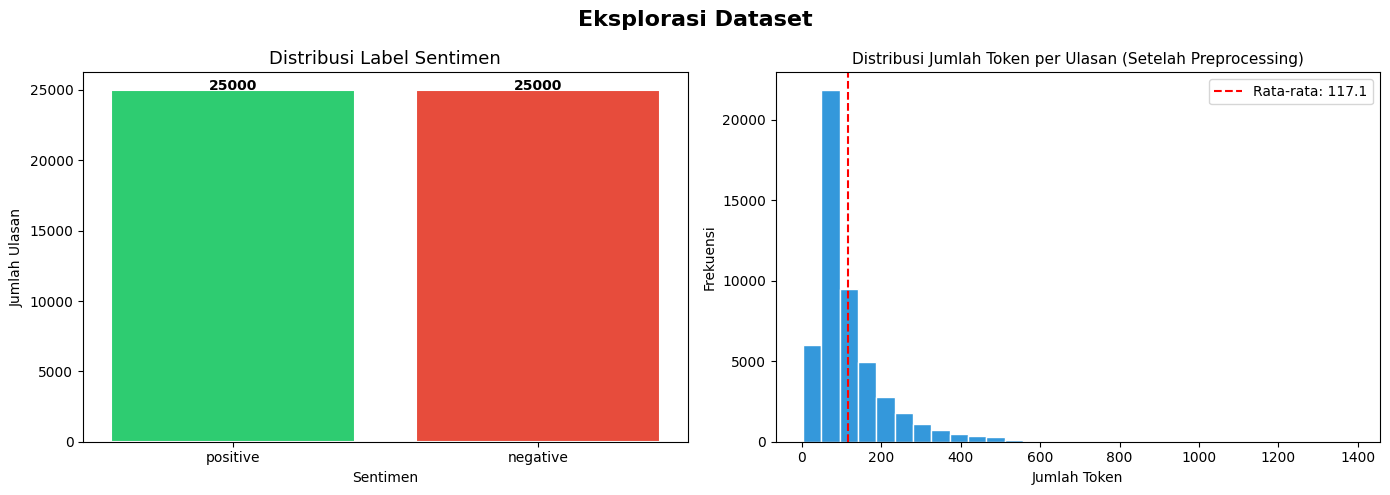

✅ Visualisasi 1 tersimpan: viz1_distribusi.png


In [ ]:
df['token_count'] = df['tokens_stem'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Eksplorasi Dataset', fontsize=16, fontweight='bold')

# Plot 1: Distribusi Sentimen
# Menunjukkan bahwa dataset seimbang (25000 positif, 25000 negatif)
sentiment_counts = df['sentiment'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Label Sentimen', fontsize=13)
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah Ulasan')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Plot 2: Distribusi Panjang Token
# Menunjukkan berapa banyak token rata-rata per ulasan setelah preprocessing
axes[1].hist(df['token_count'], bins=30, color='#3498db', edgecolor='white')
axes[1].set_title('Distribusi Jumlah Token per Ulasan (Setelah Preprocessing)', fontsize=11)
axes[1].set_xlabel('Jumlah Token')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(df['token_count'].mean(), color='red', linestyle='--',
                label=f'Rata-rata: {df["token_count"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('viz1_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi 1 tersimpan: viz1_distribusi.png')

### Visualisasi 2: Word Cloud

Word Cloud menampilkan kata-kata yang paling sering muncul pada masing-masing kelas sentimen.
Semakin besar ukuran kata, semakin tinggi frekuensinya.

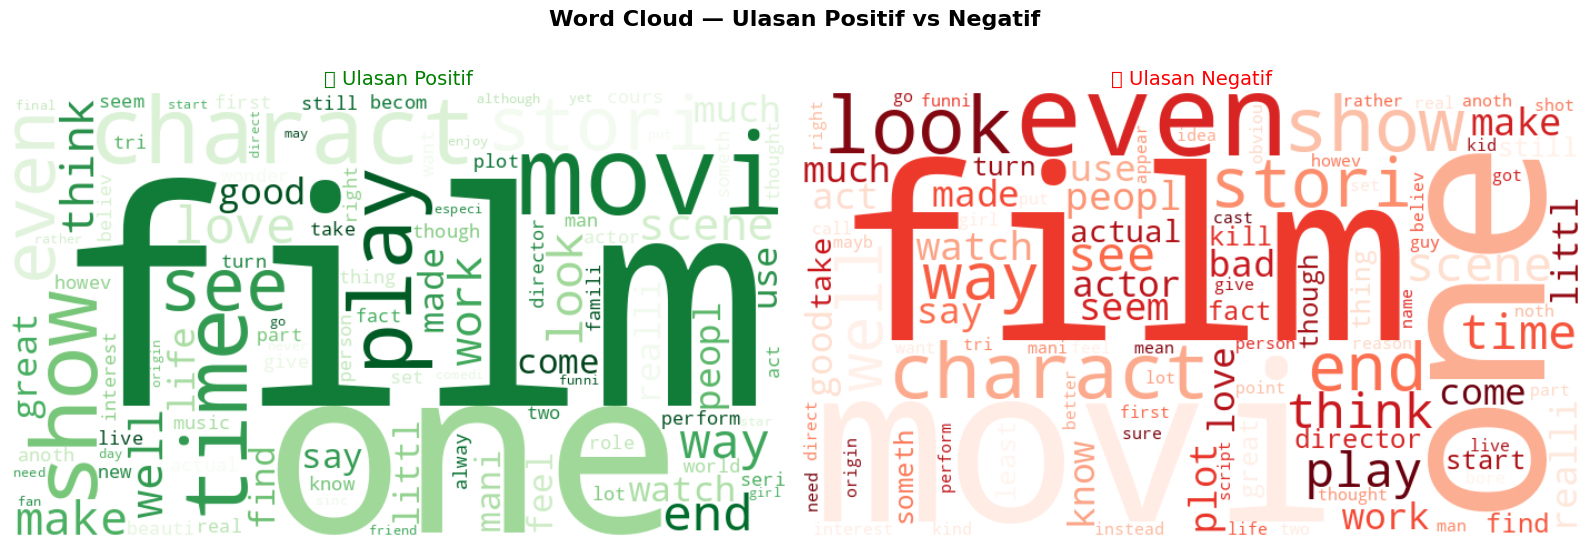

✅ Visualisasi 2 tersimpan: viz2_wordcloud.png


In [ ]:
# Gabungkan semua teks per kelas sentimen
pos_text = ' '.join(df[df['sentiment'] == 'positive']['text_stem'])
neg_text = ' '.join(df[df['sentiment'] == 'negative']['text_stem'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word Cloud — Ulasan Positif vs Negatif', fontsize=16, fontweight='bold')

# Word cloud ulasan positif (warna hijau)
wc_pos = WordCloud(width=700, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('✅ Ulasan Positif', fontsize=14, color='green')
axes[0].axis('off')

# Word cloud ulasan negatif (warna merah)
wc_neg = WordCloud(width=700, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('❌ Ulasan Negatif', fontsize=14, color='red')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('viz2_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi 2 tersimpan: viz2_wordcloud.png')

### Visualisasi 3: Top 20 Kata Paling Sering Muncul

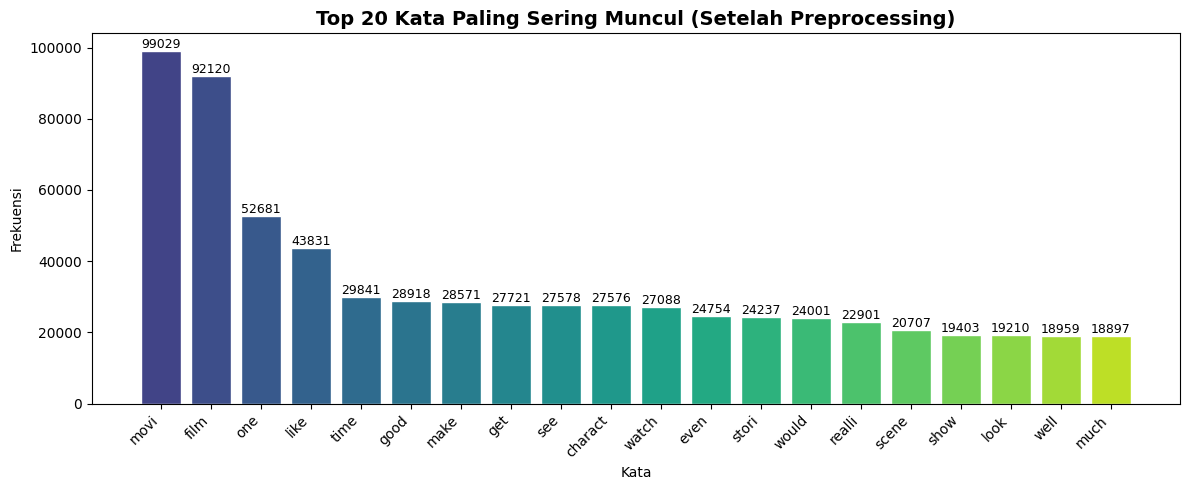

✅ Visualisasi 3 tersimpan: viz3_token_freq.png


In [ ]:
from collections import Counter

# Hitung frekuensi semua token di seluruh dataset
all_tokens = [t for tokens in df['tokens_stem'] for t in tokens]
token_freq = Counter(all_tokens).most_common(20)
words, counts = zip(*token_freq)

plt.figure(figsize=(12, 5))
bars = plt.bar(words, counts, color=plt.cm.viridis(np.linspace(0.2, 0.9, 20)), edgecolor='white')
plt.title('Top 20 Kata Paling Sering Muncul (Setelah Preprocessing)', fontsize=14, fontweight='bold')
plt.xlabel('Kata')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45, ha='right')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('viz3_token_freq.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi 3 tersimpan: viz3_token_freq.png')

---
# Bagian 4 — Representasi Teks

Representasi teks adalah proses mengubah teks menjadi vektor numerik agar dapat diproses oleh algoritma machine learning.
Tiga metode yang dibandingkan:

| Metode | Konsep | Kelebihan | Kekurangan |
|---|---|---|---|
| **BoW** | Hitung frekuensi kata | Sederhana, cepat | Abaikan urutan & konteks |
| **TF-IDF** | Bobot kata berdasarkan kepentingan | Lebih informatif dari BoW | Masih abaikan semantik |
| **Word2Vec** | Vektor dense berbasis konteks | Tangkap relasi semantik | Butuh banyak data |

In [ ]:
# Split data training dan testing (80:20)
# stratify=y memastikan proporsi kelas seimbang di train dan test
X = df['text_stem']
y = df['sentiment'].map({'positive': 1, 'negative': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'✅ Data split selesai!')
print(f'   Training : {len(X_train)} sampel (80%)')
print(f'   Testing  : {len(X_test)} sampel (20%)')

✅ Data split selesai!
   Training : 40000 sampel (80%)
   Testing  : 10000 sampel (20%)


## 4A. Bag-of-Words (BoW)

BoW merepresentasikan dokumen sebagai vektor frekuensi kata. Setiap dimensi = satu kata dalam kosakata.
Parameter `ngram_range=(1,2)` berarti kita juga memperhitungkan pasangan kata (bigram).

In [ ]:
# Bag-of-Words dengan CountVectorizer
# max_features=5000 → hanya gunakan 5000 kata paling sering
# ngram_range=(1,2) → unigram dan bigram
bow_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bow = bow_vectorizer.fit_transform(X_train)  # fit di training, transform ke matrix
X_test_bow  = bow_vectorizer.transform(X_test)       # hanya transform (jangan fit ulang)

print('=== Bag-of-Words ===')
print(f'Dimensi matrix training : {X_train_bow.shape}  (dokumen x fitur)')
print(f'Dimensi matrix testing  : {X_test_bow.shape}')
print(f'10 fitur pertama: {bow_vectorizer.get_feature_names_out()[:10].tolist()}')

=== Bag-of-Words ===
Dimensi matrix training : (40000, 5000)  (dokumen x fitur)
Dimensi matrix testing  : (10000, 5000)
10 fitur pertama: ['abandon', 'abc', 'abil', 'abl', 'abort', 'absenc', 'absolut', 'absolut love', 'absolut noth', 'absorb']


## 4B. TF-IDF (Term Frequency — Inverse Document Frequency)

**TF (Term Frequency)** = seberapa sering kata muncul dalam dokumen.
**IDF (Inverse Document Frequency)** = seberapa jarang kata muncul di seluruh koleksi.

**TF-IDF = TF × IDF** → kata yang sering muncul di satu dokumen tapi jarang di dokumen lain mendapat bobot tinggi.

In [ ]:
# TF-IDF dengan TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print('=== TF-IDF ===')
print(f'Dimensi matrix training : {X_train_tfidf.shape}')
print(f'Dimensi matrix testing  : {X_test_tfidf.shape}')
print(f'10 fitur pertama: {tfidf_vectorizer.get_feature_names_out()[:10].tolist()}')

=== TF-IDF ===
Dimensi matrix training : (40000, 5000)
Dimensi matrix testing  : (10000, 5000)
10 fitur pertama: ['abandon', 'abc', 'abil', 'abl', 'abort', 'absenc', 'absolut', 'absolut love', 'absolut noth', 'absorb']


### Visualisasi 4: Plot TF-IDF Score — Top Kata per Kelas

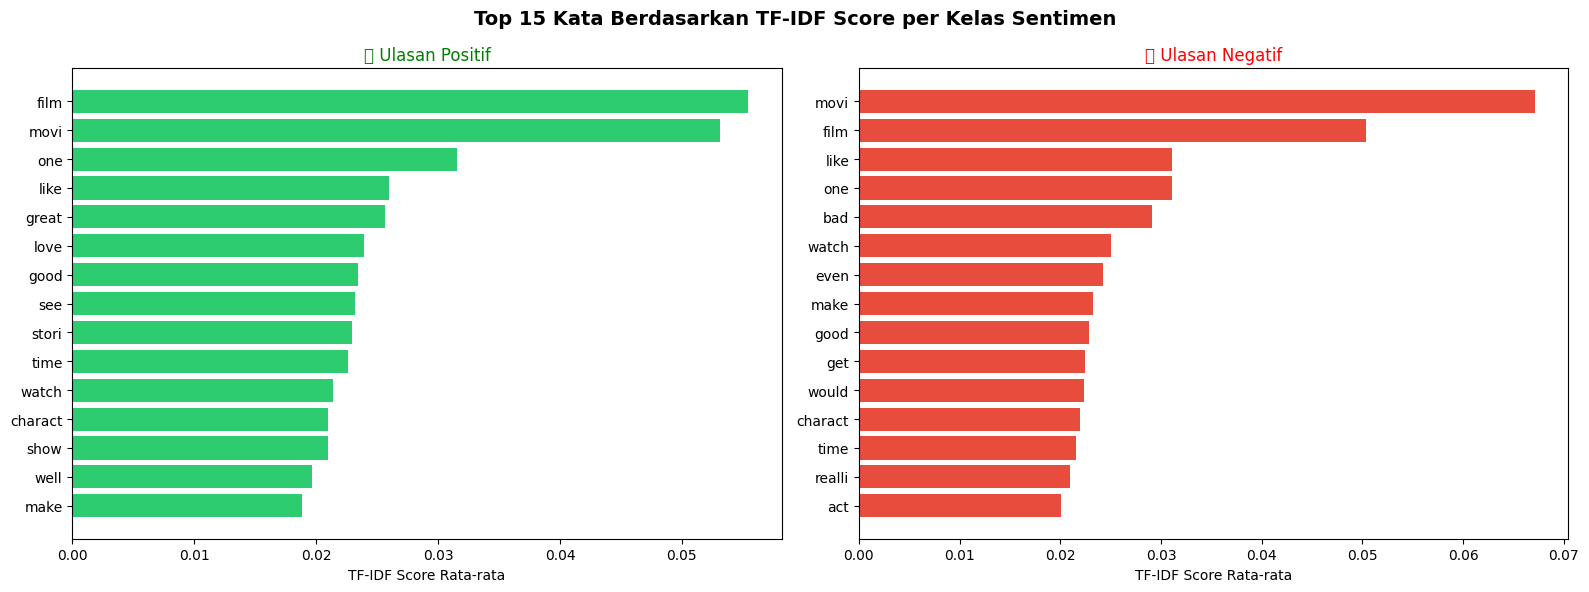

✅ Visualisasi 4 tersimpan: viz4_tfidf_plot.png


In [ ]:
# Hitung rata-rata TF-IDF score per kata untuk masing-masing kelas
feature_names  = tfidf_vectorizer.get_feature_names_out()
X_full_tfidf   = tfidf_vectorizer.transform(df['text_stem'])

pos_mask = df['sentiment'].values == 'positive'
neg_mask = df['sentiment'].values == 'negative'

pos_scores = np.asarray(X_full_tfidf[pos_mask].mean(axis=0)).flatten()
neg_scores = np.asarray(X_full_tfidf[neg_mask].mean(axis=0)).flatten()

top_n = 15
top_pos_idx = pos_scores.argsort()[-top_n:][::-1]
top_neg_idx = neg_scores.argsort()[-top_n:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 15 Kata Berdasarkan TF-IDF Score per Kelas Sentimen', fontsize=14, fontweight='bold')

axes[0].barh(feature_names[top_pos_idx][::-1], pos_scores[top_pos_idx][::-1], color='#2ecc71')
axes[0].set_title('✅ Ulasan Positif', color='green', fontsize=12)
axes[0].set_xlabel('TF-IDF Score Rata-rata')

axes[1].barh(feature_names[top_neg_idx][::-1], neg_scores[top_neg_idx][::-1], color='#e74c3c')
axes[1].set_title('❌ Ulasan Negatif', color='red', fontsize=12)
axes[1].set_xlabel('TF-IDF Score Rata-rata')

plt.tight_layout()
plt.savefig('viz4_tfidf_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi 4 tersimpan: viz4_tfidf_plot.png')

## 4C. Word2Vec (Word Embeddings)

Word2Vec melatih jaringan neural sederhana untuk memprediksi kata berdasarkan konteksnya.
Hasilnya adalah vektor dense (padat) berdimensi rendah untuk setiap kata.

- **vector_size=100**: setiap kata direpresentasikan oleh 100 angka
- **window=5**: model melihat 5 kata di kiri dan kanan sebagai konteks
- **min_count=2**: abaikan kata yang muncul kurang dari 2 kali

In [ ]:
# Training Word2Vec
sentences = df['tokens_stem'].tolist()

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,  # dimensi embedding
    window=5,         # ukuran context window
    min_count=2,      # abaikan kata dengan frekuensi < 2
    workers=4,        # jumlah CPU core
    epochs=10,        # iterasi training
    seed=42
)

print(f'✅ Word2Vec berhasil ditraining!')
print(f'   Vocabulary : {len(w2v_model.wv)} kata unik')
print(f'   Dimensi    : {w2v_model.vector_size}')

# Tampilkan kata-kata yang paling mirip dengan 'good'
if 'good' in w2v_model.wv:
    print(f'\n   Kata paling mirip dengan "good":')
    for word, score in w2v_model.wv.most_similar('good', topn=5):
        print(f'     {word}: {score:.4f}')

✅ Word2Vec berhasil ditraining!
   Vocabulary : 58237 kata unik
   Dimensi    : 100

   Kata paling mirip dengan "good":
     decent: 0.7697
     great: 0.7206
     bad: 0.6722
     nice: 0.6137
     alright: 0.5961


In [ ]:
# Fungsi: ubah list token menjadi 1 vektor dokumen
# Caranya: rata-rata (mean) dari semua vektor kata dalam dokumen
def doc_to_vec(tokens, model, vector_size=100):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(vector_size)

# Buat matrix fitur Word2Vec untuk seluruh dataset
X_w2v = np.array([doc_to_vec(tokens, w2v_model) for tokens in df['tokens_stem']])

X_train_w2v = X_w2v[X_train.index]
X_test_w2v  = X_w2v[X_test.index]

print(f'✅ Document vectors berhasil dibuat!')
print(f'   Shape X_train_w2v : {X_train_w2v.shape}  (dokumen x dimensi)')
print(f'   Shape X_test_w2v  : {X_test_w2v.shape}')

✅ Document vectors berhasil dibuat!
   Shape X_train_w2v : (40000, 100)  (dokumen x dimensi)
   Shape X_test_w2v  : (10000, 100)


### Visualisasi 5: Word Embedding dengan PCA

PCA (Principal Component Analysis) digunakan untuk mereduksi dimensi dari 100D ke 2D,
sehingga kita bisa memvisualisasikan kedekatan kata-kata dalam ruang embedding.

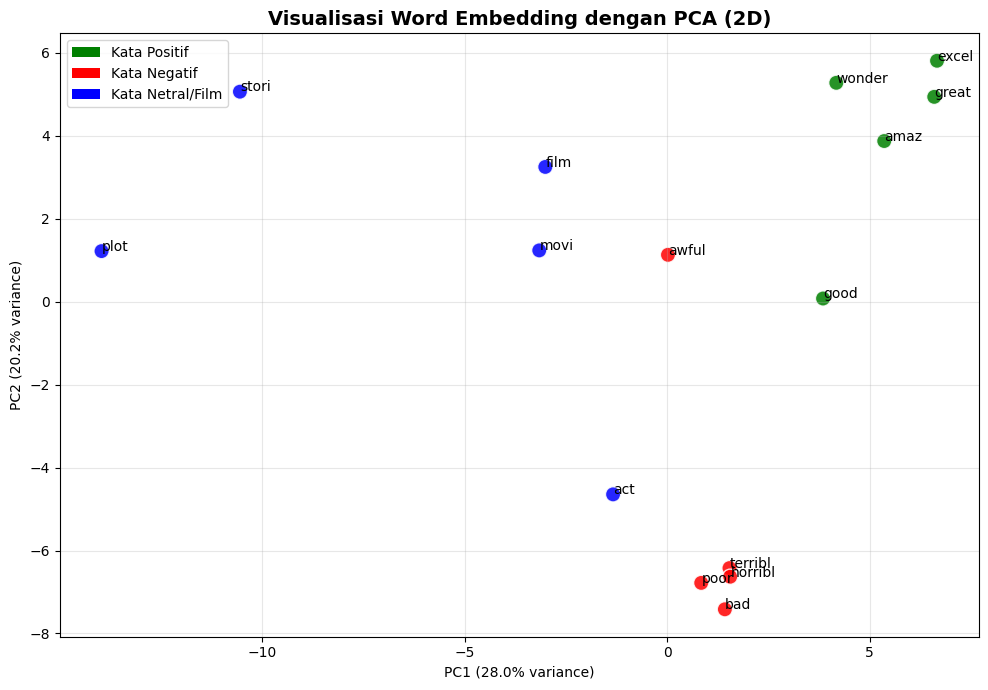

✅ Visualisasi 5 tersimpan: viz5_pca_embedding.png


In [ ]:
from matplotlib.patches import Patch

# Kata-kata yang ingin divisualisasikan (bentuk stemmed)
words_to_plot = ['good', 'great', 'excel', 'wonder', 'amaz',
                 'bad', 'terribl', 'awful', 'horribl', 'poor',
                 'movi', 'film', 'act', 'plot', 'stori']
words_to_plot = [w for w in words_to_plot if w in w2v_model.wv]

if len(words_to_plot) >= 5:
    vectors = np.array([w2v_model.wv[w] for w in words_to_plot])

    # Reduksi dimensi dari 100D ke 2D
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(vectors)

    colors_map = {
        'good': 'green', 'great': 'green', 'excel': 'green', 'wonder': 'green', 'amaz': 'green',
        'bad': 'red',   'terribl': 'red',  'awful': 'red',   'horribl': 'red',  'poor': 'red',
        'movi': 'blue', 'film': 'blue',    'act': 'blue',    'plot': 'blue',    'stori': 'blue'
    }
    point_colors = [colors_map.get(w, 'gray') for w in words_to_plot]

    plt.figure(figsize=(10, 7))
    plt.scatter(coords[:, 0], coords[:, 1], c=point_colors, s=120, alpha=0.85, edgecolors='white')
    for i, word in enumerate(words_to_plot):
        plt.annotate(word, (coords[i, 0] + 0.005, coords[i, 1] + 0.005), fontsize=10)

    legend_elements = [
        Patch(facecolor='green', label='Kata Positif'),
        Patch(facecolor='red',   label='Kata Negatif'),
        Patch(facecolor='blue',  label='Kata Netral/Film')
    ]
    plt.legend(handles=legend_elements)
    plt.title('Visualisasi Word Embedding dengan PCA (2D)', fontsize=14, fontweight='bold')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('viz5_pca_embedding.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Visualisasi 5 tersimpan: viz5_pca_embedding.png')

---
# Bagian 5 — Klasifikasi & Perbandingan Performa

Untuk mengevaluasi kualitas masing-masing representasi teks, kita melatih classifier:
- **Naive Bayes (MultinomialNB)**: cocok untuk fitur sparse seperti BoW dan TF-IDF
- **Logistic Regression**: cocok untuk fitur dense seperti Word2Vec

Metrik evaluasi yang digunakan:
- **Accuracy**: persentase prediksi yang benar
- **Precision**: dari semua yang diprediksi positif, berapa yang benar-benar positif?
- **Recall**: dari semua yang sebenarnya positif, berapa yang berhasil dideteksi?
- **F1-Score**: rata-rata harmonis precision dan recall

In [ ]:
results = {}

def evaluate_model(name, model, X_test, y_test):
    """Evaluasi model dan simpan hasil metrik."""
    y_pred  = model.predict(X_test)
    acc     = accuracy_score(y_test, y_pred)
    report  = classification_report(y_test, y_pred, target_names=['Negatif', 'Positif'])
    cm      = confusion_matrix(y_test, y_pred)
    results[name] = {'accuracy': acc, 'report': report, 'cm': cm}
    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    print(report)

# 1. BoW + Naive Bayes
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
evaluate_model('BoW + Naive Bayes', nb_bow, X_test_bow, y_test)

# 2. TF-IDF + Naive Bayes
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
evaluate_model('TF-IDF + Naive Bayes', nb_tfidf, X_test_tfidf, y_test)

# 3. Word2Vec + Logistic Regression
lr_w2v = LogisticRegression(random_state=42, max_iter=1000)
lr_w2v.fit(X_train_w2v, y_train)
evaluate_model('Word2Vec + Logistic Regression', lr_w2v, X_test_w2v, y_test)


=== BoW + Naive Bayes ===
Accuracy: 0.8471 (84.71%)
              precision    recall  f1-score   support

     Negatif       0.85      0.85      0.85      5000
     Positif       0.85      0.84      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


=== TF-IDF + Naive Bayes ===
Accuracy: 0.8580 (85.80%)
              precision    recall  f1-score   support

     Negatif       0.86      0.85      0.86      5000
     Positif       0.85      0.87      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


=== Word2Vec + Logistic Regression ===
Accuracy: 0.8669 (86.69%)
              precision    recall  f1-score   support

     Negatif       0.87      0.86      0.87      5000
     Positif       0.86      0.87      0.87      5000

    acc

### Visualisasi 6: Perbandingan Akurasi & Confusion Matrix

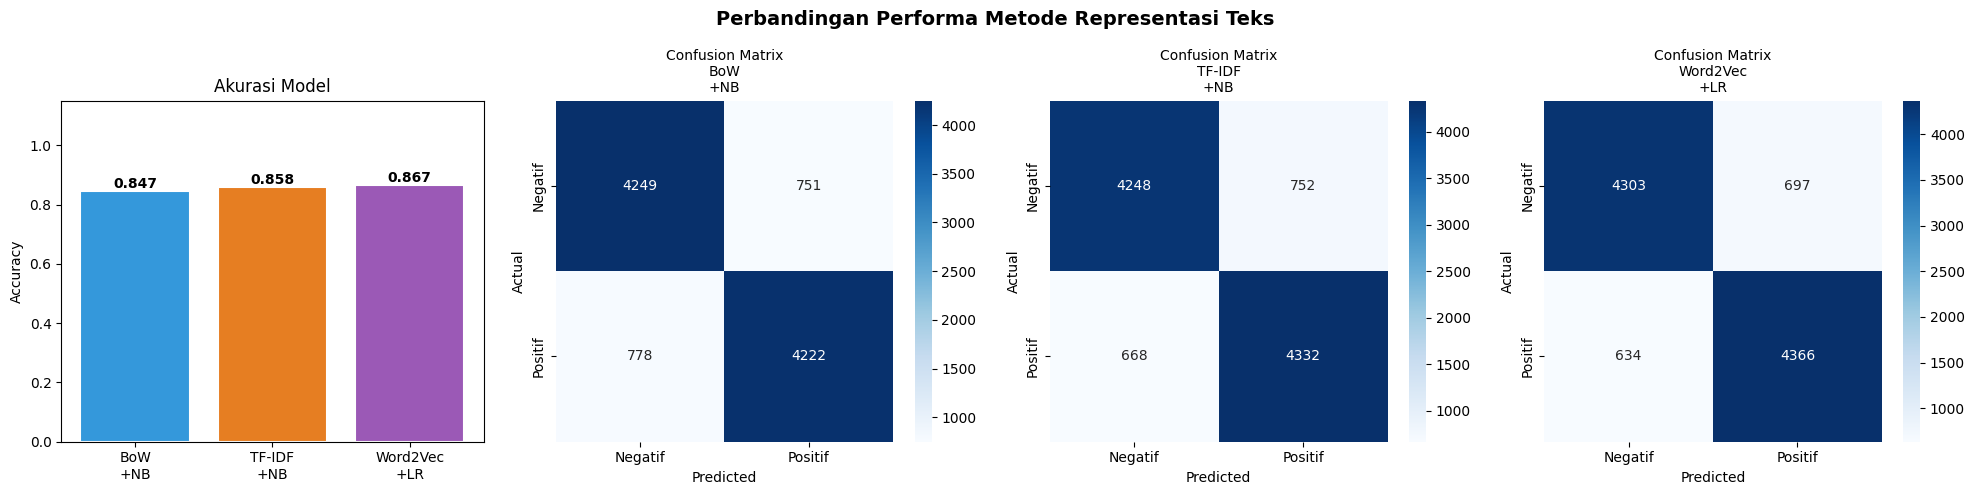

✅ Visualisasi 6 tersimpan: viz6_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Perbandingan Performa Metode Representasi Teks', fontsize=14, fontweight='bold')

method_names = list(results.keys())
accuracies   = [results[m]['accuracy'] for m in method_names]
short_names  = ['BoW\n+NB', 'TF-IDF\n+NB', 'Word2Vec\n+LR']
bar_colors   = ['#3498db', '#e67e22', '#9b59b6']

# Bar chart akurasi
bars = axes[0].bar(short_names, accuracies, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Akurasi Model', fontsize=12)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.15)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{acc:.3f}', ha='center', fontweight='bold')

# Confusion Matrix untuk masing-masing metode
for idx, name in enumerate(method_names):
    ax = axes[idx + 1]
    cm = results[name]['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negatif', 'Positif'],
                yticklabels=['Negatif', 'Positif'])
    ax.set_title(f'Confusion Matrix\n{short_names[idx]}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('viz6_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi 6 tersimpan: viz6_comparison.png')

---
# Bagian 6 — Analisis & Kesimpulan

In [ ]:
print('=' * 65)
print('    RINGKASAN PERBANDINGAN METODE REPRESENTASI TEKS')
print('=' * 65)
print(f'{"Metode":<35} {"Akurasi":>10} {"Rank":>8}')
print('-' * 65)

sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
for rank, (name, res) in enumerate(sorted_results, 1):
    print(f'{name:<35} {res["accuracy"]:>9.4f} {rank:>7}')

best_method = sorted_results[0][0]
best_acc    = sorted_results[0][1]['accuracy']

print('=' * 65)
print(f'\n🏆 Metode Terbaik : {best_method}')
print(f'   Akurasi       : {best_acc:.4f} ({best_acc*100:.2f}%)')

print('''
=== KESIMPULAN ===

1. TEXT PREPROCESSING
   Proses cleaning, tokenisasi, stopword removal, dan stemming
   sangat penting untuk mengurangi noise sebelum pemodelan.
   Stemming lebih agresif namun lebih cepat dari lemmatization.

2. BAG-OF-WORDS (BoW)
   Representasi paling sederhana berbasis frekuensi kata.
   Mudah diimplementasi namun mengabaikan urutan dan konteks.

3. TF-IDF
   Memberi bobot lebih tinggi pada kata yang informatif.
   Secara umum lebih baik dari BoW untuk klasifikasi teks.

4. WORD2VEC
   Menangkap relasi semantik antar kata dalam ruang vektor.
   Perlu data lebih banyak untuk performa optimal.
   Rata-rata vektor kata belum tentu optimal untuk klasifikasi.
''')

    RINGKASAN PERBANDINGAN METODE REPRESENTASI TEKS
Metode                                 Akurasi     Rank
-----------------------------------------------------------------
Word2Vec + Logistic Regression         0.8669       1
TF-IDF + Naive Bayes                   0.8580       2
BoW + Naive Bayes                      0.8471       3

🏆 Metode Terbaik : Word2Vec + Logistic Regression
   Akurasi       : 0.8669 (86.69%)

=== KESIMPULAN ===

1. TEXT PREPROCESSING
   Proses cleaning, tokenisasi, stopword removal, dan stemming
   sangat penting untuk mengurangi noise sebelum pemodelan.
   Stemming lebih agresif namun lebih cepat dari lemmatization.

2. BAG-OF-WORDS (BoW)
   Representasi paling sederhana berbasis frekuensi kata.
   Mudah diimplementasi namun mengabaikan urutan dan konteks.

3. TF-IDF
   Memberi bobot lebih tinggi pada kata yang informatif.
   Secara umum lebih baik dari BoW untuk klasifikasi teks.

4. WORD2VEC
   Menangkap relasi semantik antar kata dalam ruang vektor.
   Pe

---
# Bagian 7 — Demo Prediksi Sentimen

Pada bagian ini dilakukan pengujian model yang telah dilatih untuk memprediksi sentimen dari teks baru yang belum pernah dilihat sebelumnya (unseen data).

Teks input akan melalui tahap preprocessing yang sama seperti data latih, kemudian direpresentasikan menggunakan metode Bag-of-Words, TF-IDF, atau Word2Vec.

Hasil prediksi yang dihasilkan berupa label sentimen (positif atau negatif) beserta tingkat kepercayaan (confidence score) dari model.

In [ ]:
test_texts = [
    "This movie was absolutely fantastic! Great acting and amazing story.",
    "Terrible film, completely boring and waste of time. Very disappointing.",
    "The movie was okay, not too good but not too bad ether."
]

def predict_sentiment(text, use_method='tfidf'):
    tokens = full_preprocessing(text, use_stemming=True)
    text_p = ' '.join(tokens)

    if use_method == 'bow':
        vec  = bow_vectorizer.transform([text_p])
        pred = nb_bow.predict(vec)[0]
        prob = nb_bow.predict_proba(vec)[0]

    elif use_method == 'tfidf':
        vec  = tfidf_vectorizer.transform([text_p])
        pred = nb_tfidf.predict(vec)[0]
        prob = nb_tfidf.predict_proba(vec)[0]

    elif use_method == 'word2vec':
        vec = doc_to_vec(tokens, w2v_model)

        if vec is None or len(vec) == 0:
            return "⚠️ Tidak bisa diprediksi", 0

        vec  = vec.reshape(1, -1)
        pred = lr_w2v.predict(vec)[0]
        prob = lr_w2v.predict_proba(vec)[0]

    else:
        raise ValueError("Method harus: 'bow', 'tfidf', atau 'word2vec'")

    # FIX label
    if pred in ['positive', 1]:
        label = '✅ POSITIF'
    else:
        label = '❌ NEGATIF'

    confidence = max(prob) * 100
    return label, confidence


print('=== DEMO PREDIKSI SENTIMEN ===')
for text in test_texts:
    label_bow,   conf_bow   = predict_sentiment(text, 'bow')
    label_tfidf, conf_tfidf = predict_sentiment(text, 'tfidf')
    label_w2v,   conf_w2v   = predict_sentiment(text, 'word2vec')
    print(f'\n📝 Input: "{text[:60]}"')
    print(f'   BoW     : {label_bow}   ({conf_bow:.1f}% confidence)')
    print(f'   TF-IDF  : {label_tfidf} ({conf_tfidf:.1f}% confidence)')
    print(f'   Word2Vec: {label_w2v} ({conf_w2v:.1f}% confidence)')

=== DEMO PREDIKSI SENTIMEN ===

📝 Input: "This movie was absolutely fantastic! Great acting and amazin"
   BoW     : ✅ POSITIF   (96.4% confidence)
   TF-IDF  : ✅ POSITIF (78.8% confidence)
   Word2Vec: ✅ POSITIF (100.0% confidence)

📝 Input: "Terrible film, completely boring and waste of time. Very dis"
   BoW     : ❌ NEGATIF   (100.0% confidence)
   TF-IDF  : ❌ NEGATIF (97.9% confidence)
   Word2Vec: ❌ NEGATIF (100.0% confidence)

📝 Input: "The movie was okay, not too good but not too bad ether."
   BoW     : ❌ NEGATIF   (92.4% confidence)
   TF-IDF  : ❌ NEGATIF (71.9% confidence)
   Word2Vec: ❌ NEGATIF (99.9% confidence)


# 📚 Referensi

1. Jurafsky, D. & Martin, J. H. (2023). *Speech and Language Processing* (3rd ed.). Prentice Hall.  
2. Bird, S., Klein, E., & Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly.  
3. Maas, A. L., Daly, R. E., Pham, P. T., Huang, D., Ng, A. Y., & Potts, C. (2011).  
   Learning Word Vectors for Sentiment Analysis. *Proceedings of the 49th Annual Meeting of the Association for Computational Linguistics (ACL)*.  
4. Dataset: IMDB Movie Review Dataset (50K Reviews). Tersedia di Kaggle:  
   https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews  
5. Mikolov, T., et al. (2013). Efficient Estimation of Word Representations in Vector Space. *ICLR*.  
6. NLTK Documentation: https://www.nltk.org/  
7. Gensim Word2Vec: https://radimrehurek.com/gensim/models/word2vec.html  
8. Scikit-learn Documentation: https://scikit-learn.org/stable/  